In [1]:
print("Boston Housing Price Prediction")

Boston Housing Price Prediction


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
df = pd.read_csv(r"D:\sem 5\devops\archive\HousingData.csv")

In [4]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [5]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [6]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,NaN,2.5050,1,273,21.0,396.90,7.88,11.9


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 506
Columns : 14


In [8]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [9]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [10]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

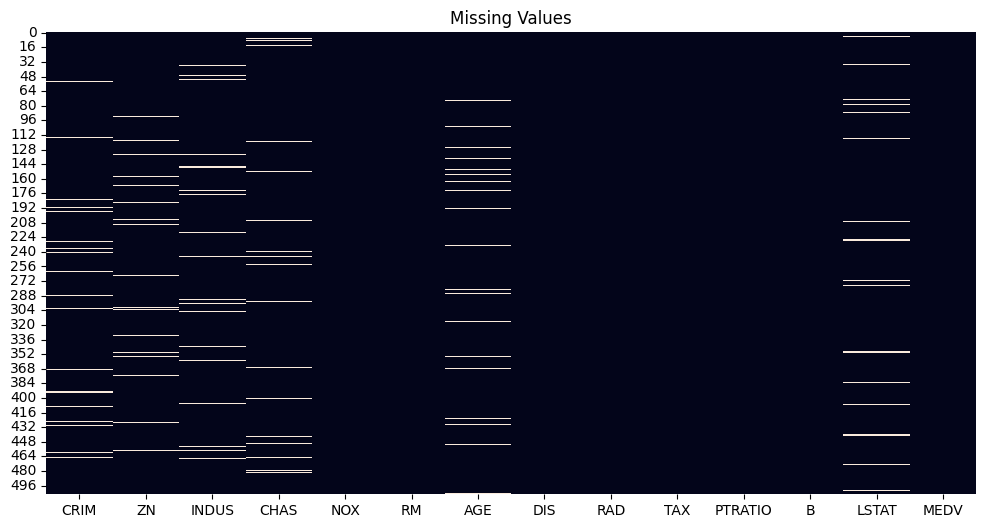

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [12]:
imputer = SimpleImputer(strategy="median")

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,11.43,36.2


In [13]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [14]:
print(df.duplicated().sum())

0


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
corr = df.corr()

corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.185359,0.392632,-0.055585,0.410971,-0.220045,0.343427,-0.366025,0.601224,0.560469,0.277964,-0.365336,0.437417,-0.383895
ZN,-0.185359,1.000000,-0.507304,-0.032992,-0.498619,0.312295,-0.535341,0.632428,-0.300061,-0.304385,-0.394622,0.170125,-0.398838,0.362292
INDUS,0.392632,-0.507304,1.000000,0.054693,0.738387,-0.377978,0.614248,-0.698621,0.592735,0.716267,0.385366,-0.354840,0.564508,-0.476394
CHAS,-0.055585,-0.032992,0.054693,1.000000,0.070867,0.106797,0.074984,-0.092318,-0.003339,-0.035822,-0.109451,0.050608,-0.047279,0.183844
NOX,0.410971,-0.498619,0.738387,0.070867,1.000000,-0.302188,0.711864,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.573040,-0.427321
RM,-0.220045,0.312295,-0.377978,0.106797,-0.302188,1.000000,-0.239518,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.604323,0.695360
AGE,0.343427,-0.535341,0.614248,0.074984,0.711864,-0.239518,1.000000,-0.724354,0.447088,0.498408,0.261826,-0.268029,0.575022,-0.377572
DIS,-0.366025,0.632428,-0.698621,-0.092318,-0.769230,0.205246,-0.724354,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.483244,0.249929
RAD,0.601224,-0.300061,0.592735,-0.003339,0.611441,-0.209847,0.447088,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.467765,-0.381626
TAX,0.560469,-0.304385,0.716267,-0.035822,0.668023,-0.292048,0.498408,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.524156,-0.468536


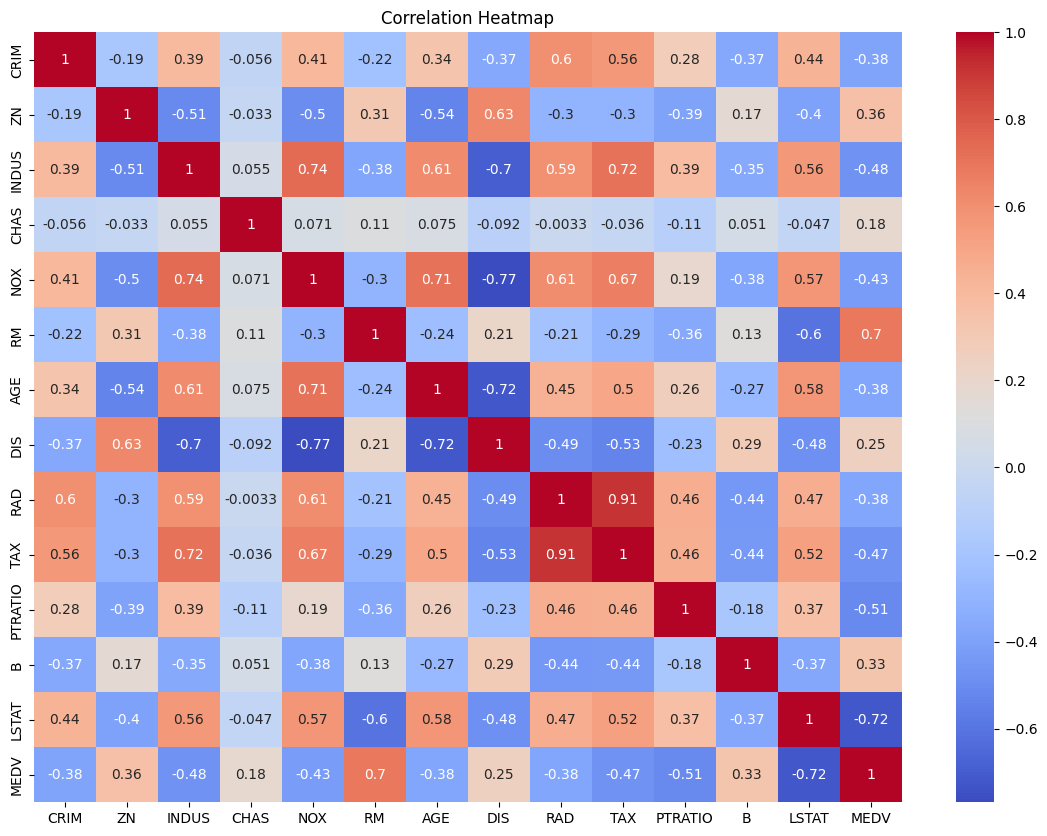

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

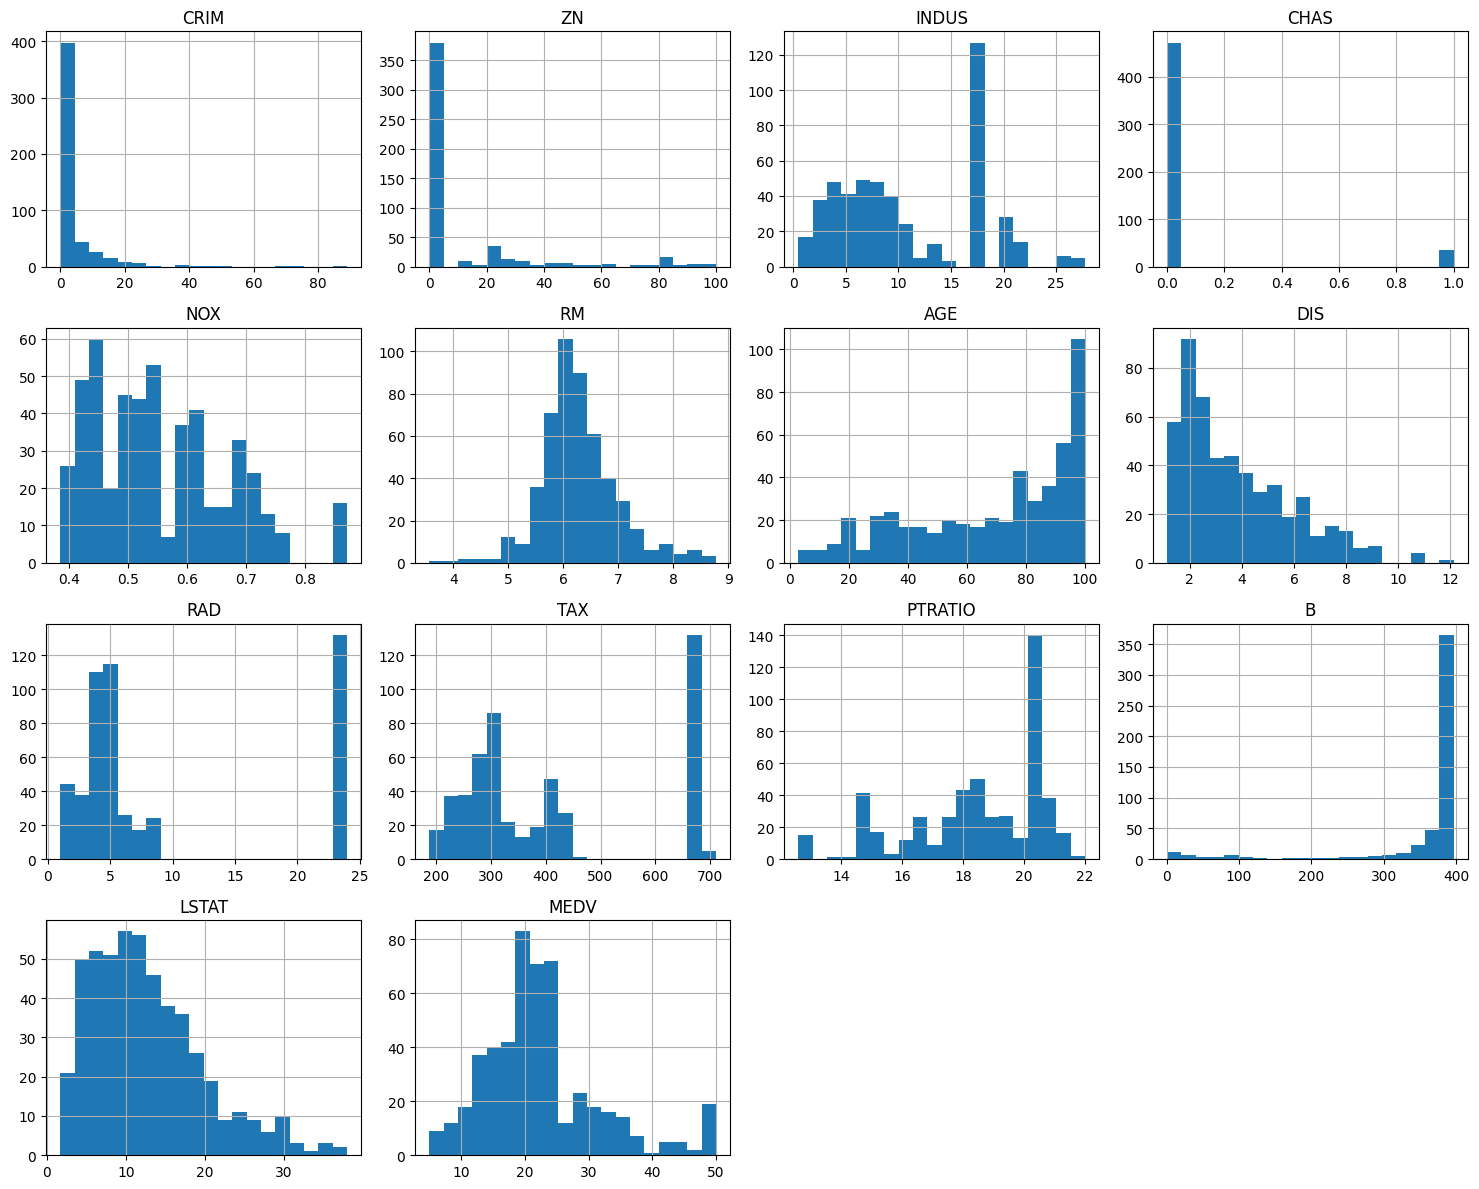

In [18]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

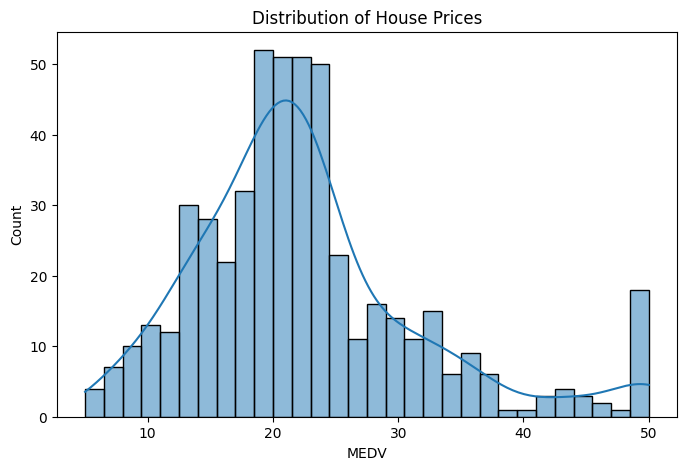

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MEDV"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")

plt.show()

In [20]:
X = df.drop("MEDV", axis=1)

y = df["MEDV"]

print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :",X_train.shape)

print("Testing Samples :",X_test.shape)

Training Samples : (404, 13)
Testing Samples : (102, 13)


In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [23]:
lr = LinearRegression()

lr.fit(X_train,y_train)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [24]:
lr_pred = lr.predict(X_test)

In [25]:
print("MAE :",mean_absolute_error(y_test,lr_pred))

print("MSE :",mean_squared_error(y_test,lr_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,lr_pred)))

print("R2 Score :",r2_score(y_test,lr_pred))

MAE : 3.1487373170237607
MSE : 24.999384790103356
RMSE : 4.999938478631848
R2 Score : 0.6591013893903512


In [26]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train,y_train)

print("Decision Tree Model Trained")

Decision Tree Model Trained


In [27]:
dt_pred = dt.predict(X_test)

In [28]:
print("MAE :",mean_absolute_error(y_test,dt_pred))

print("MSE :",mean_squared_error(y_test,dt_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,dt_pred)))

print("R2 Score :",r2_score(y_test,dt_pred))

MAE : 2.895098039215686
MSE : 23.393039215686272
RMSE : 4.8366351129360865
R2 Score : 0.681005967405988


In [29]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


In [30]:
rf_pred = rf.predict(X_test)

In [31]:
print("MAE :",mean_absolute_error(y_test,rf_pred))

print("MSE :",mean_squared_error(y_test,rf_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,rf_pred)))

print("R2 Score :",r2_score(y_test,rf_pred))

MAE : 2.070078431372548
MSE : 8.677986147058823
RMSE : 2.9458421795912324
R2 Score : 0.8816645511375442


In [32]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score":[
        r2_score(y_test,lr_pred),
        r2_score(y_test,dt_pred),
        r2_score(y_test,rf_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,lr_pred)),
        np.sqrt(mean_squared_error(y_test,dt_pred)),
        np.sqrt(mean_squared_error(y_test,rf_pred))
    ]

})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.659101,4.999938
1,Decision Tree,0.681006,4.836635
2,Random Forest,0.881665,2.945842


In [33]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,RMSE
2,Random Forest,0.881665,2.945842
1,Decision Tree,0.681006,4.836635
0,Linear Regression,0.659101,4.999938


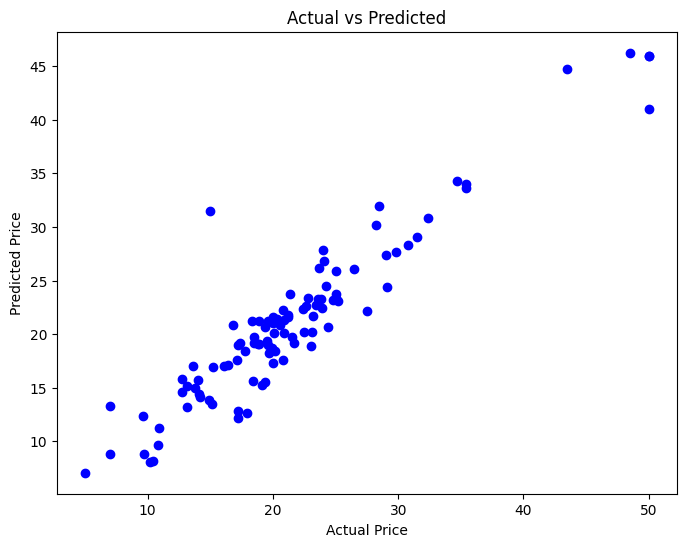

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    color='blue'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

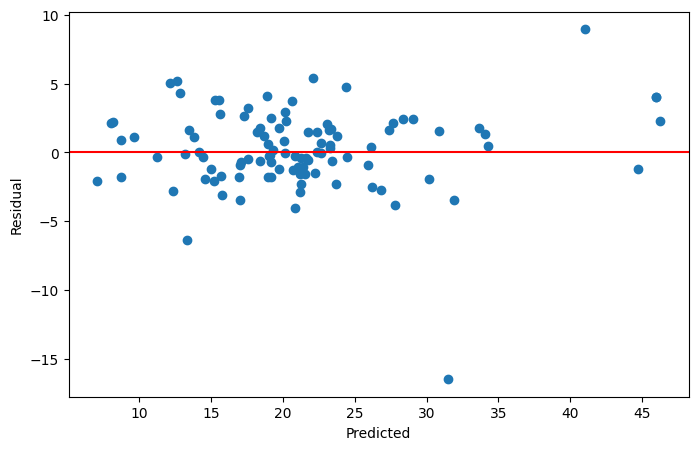

In [35]:
residual = y_test-rf_pred

plt.figure(figsize=(8,5))

plt.scatter(
    rf_pred,
    residual
)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.show()

In [36]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance

,Feature,Importance
5,RM,0.561192
12,LSTAT,0.244279
7,DIS,0.056375
0,CRIM,0.045199
10,PTRATIO,0.017237
4,NOX,0.017229
9,TAX,0.016948
11,B,0.013810
6,AGE,0.013546
2,INDUS,0.006661


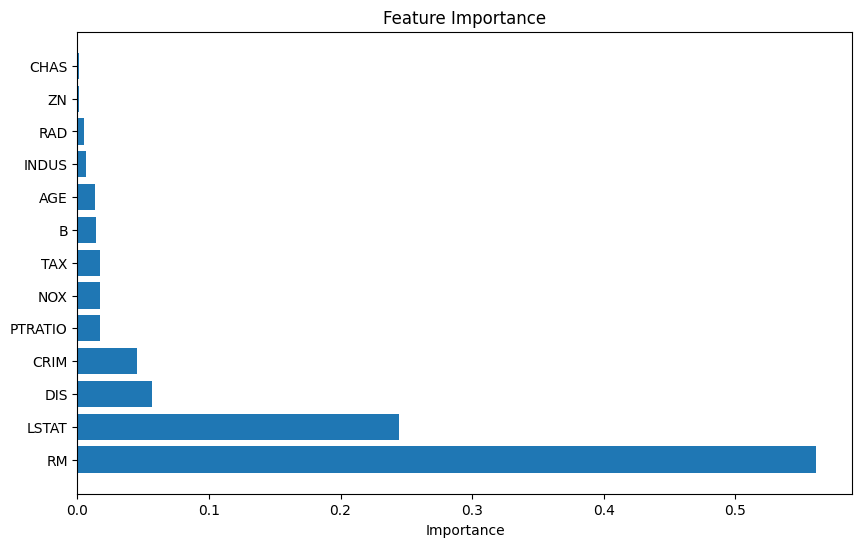

In [37]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.show()

In [38]:
sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

prediction = rf.predict(sample_scaled)

print("Predicted House Price :",prediction[0])

Predicted House Price : 27.843500000000017
